In [1]:
from censored_regressors.utils.oracle import Oracle, OracleGenerator,  RangeBoundGenerator, VariableBoundGenerator

import numpy as np

from matplotlib import pyplot as plt

In [2]:
import torch
from censored_regressors.losses.tobit_loss import RobustTobitLoss, GaussianNLLLoss

class LinearRegressionModel(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, out_features)  # Single input feature, single output

    def forward(self, x):
        return self.linear(x)

In [3]:
def optimise_lin_reg(model, x, y, loss_fn, c=None, num_iterations=1000, lr=0.05):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    # helper to ensure tensor
    def to_t(v): 
        if v is None: return None
        if not torch.is_tensor(v): 
            return torch.tensor(v, dtype=torch.float32)
        else:
            return v.float()
        # Ensure it is at least 2D (N, 1) if it's not empty
        if v.ndim == 1:
            v = v.view(-1, 1)
        return v

    x = to_t(x)
    y = to_t(y)
    c = to_t(c)
    
    if x.shape[0] != y.shape[0]:
        raise ValueError(f"Shape Mismatch! x has {x.shape[0]} samples, but y has {y.shape[0]}.")
    
    # If c is not provided, assume all data is observed (uncensored)
    if c is None:
        c = torch.zeros_like(y)
        
    if c.shape != y.shape:
        c = c.view_as(y)

    model.train()
    for epoch in range(num_iterations):
        optimizer.zero_grad()
        y_pred = model(x)
        
        # Loss calculation
        loss = loss_fn(mu_pred=y_pred, target=y, censorship=c)
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return {'model': model, 'losses': losses}

def train_and_predict(x, y, loss_fn, steps=1000, c=None):
    input_dim = 1
    if hasattr(x, 'shape') and len(x.shape) > 1:
        input_dim = x.shape[1]
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], list):
         input_dim = len(x[0])

    print(f"Initializing Model with Input Dimension: {input_dim}")
        
    model = LinearRegressionModel(input_dim, 1)
    results = optimise_lin_reg(model, x, y, loss_fn, c, steps)
    
    model.eval()
    if not torch.is_tensor(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
    else:
        x_tensor = x.float()
        
    if input_dim == 1 and x_tensor.ndim == 1:
        x_tensor = x_tensor.view(-1, 1)
        
    with torch.no_grad():
        y_pred = model(x_tensor).cpu().numpy()
    
    return {
        'model': results['model'],
        'losses': results['losses'],
        'y_pred': y_pred
    }
        

gauss_loss = GaussianNLLLoss()
tobit_loss = RobustTobitLoss()

# 2D Linear Model

In [4]:
def diagonal_bounds_2d(x, y):
    """
    Defines variable bounds based on the features x1 and x2.
    
    Args:
        x (Tensor): Shape (N, 2). x[:, 0] is x1, x[:, 1] is x2.
        y (Tensor): Shape (N,). The noisy y values (unused here, but available).
    
    Returns:
        (lower, upper): Tensors of shape (N,) or None.
    """
    x1 = x[:, 0]
    x2 = x[:, 1]

    upper_bound = 1.5 * x1 + 2.0
    
    # No lower bound
    lower_bound = None

    return lower_bound, upper_bound

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_censoring(x, y_obs, c, bound_func=None):
    """
    Plots 2D input (x1, x2) vs Output (y) in 3D.
    
    Args:
        x: (N, 2) array of inputs
        y_obs: (N,) array of observed values
        c: (N,) array of censoring indicators (0=uncensored, 1=censored)
        bound_func: Optional function to plot the censoring surface
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Split Data
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    # Create masks
    uncensored = (c.flatten() == 0)
    censored = (c.flatten() != 0)

    # 2. Plot Uncensored Data (Blue Dots)
    ax.scatter(x1[uncensored], x2[uncensored], y_obs[uncensored], 
               c='blue', marker='o', alpha=0.6, label='Uncensored')

    # 3. Plot Censored Data (Red Xs)
    # These points sit exactly on the censoring bound
    ax.scatter(x1[censored], x2[censored], y_obs[censored], 
               c='red', marker='x', s=50, label='Censored')

    # 4. (Optional) Draw the Censoring Surface
    if bound_func:
        # Create a meshgrid to plot the plane
        x1_range = np.linspace(x1.min(), x1.max(), 20)
        x2_range = np.linspace(x2.min(), x2.max(), 20)
        X1_surf, X2_surf = np.meshgrid(x1_range, x2_range)
        
        # Flatten to pass to your bound function logic
        # Note: We need to reconstruct the format your bound_func expects (N, 2)
        X_flat = np.stack([X1_surf.ravel(), X2_surf.ravel()], axis=1)
        
        # Get bounds (returns lower, upper) - we want upper for this example
        _, upper_vals = bound_func(torch.tensor(X_flat, dtype=torch.float32), None)
        
        if upper_vals is not None:
            Z_surf = upper_vals.numpy().reshape(X1_surf.shape)
            
            # Plot transparent surface
            ax.plot_surface(X1_surf, X2_surf, Z_surf, alpha=0.2, color='red')
            # Add a wireframe for better visibility
            ax.plot_wireframe(X1_surf, X2_surf, Z_surf, alpha=0.1, color='darkred')

    # 5. Labels and View
    ax.set_xlabel('Feature X1')
    ax.set_ylabel('Feature X2')
    ax.set_zlabel('Target Y')
    ax.set_title('3D View: Variable Bound Censoring')
    ax.legend()
    
    # Adjust view angle for better perspective
    ax.view_init(elev=20, azim=-80)
    
    plt.tight_layout()
    plt.show()

Loading Oracle for: $y = x_1 + x_2 + 1$
X Shape: (200, 2)
Censored Count: 49


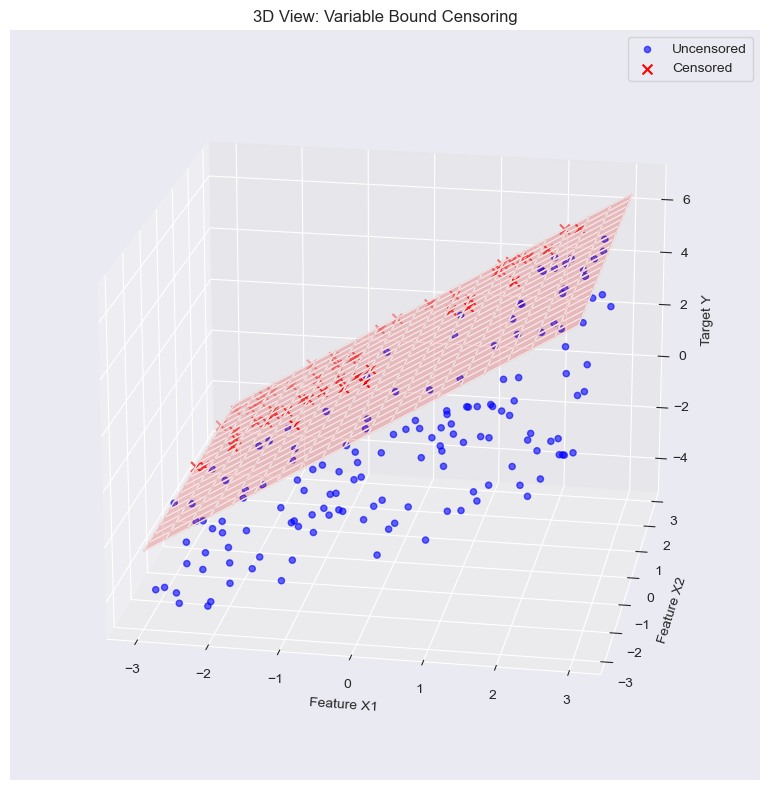

In [6]:
oracle = Oracle.from_name('linear2D') 

gen = VariableBoundGenerator(
    oracle, 
    n_samples=200, 
    dim=2,             # <--- 2D INPUTS
    noise_scale=0.5,
    bounds_generator=diagonal_bounds_2d, # <--- YOUR CUSTOM LOGIC
    start=-3.0,
    end=3.0
)

x, y, censoring, y_true = gen.generate()

print(f"X Shape: {x.shape}") # (200, 2)
print(f"Censored Count: {np.sum(censoring == 1)}")
plot_3d_censoring(x, y, censoring, bound_func=diagonal_bounds_2d)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_2d_projections(x, y_obs, c, model=None, true_fcn=None, bound_func=None):
    """
    Plots two 2D subplots:
    1. Y vs X1 (holding X2 at mean)
    2. Y vs X2 (holding X1 at mean)
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # 1. Prepare Data
    x1, x2 = x[:, 0], x[:, 1]
    x1_mean = x1.mean()
    x2_mean = x2.mean()
    
    uncensored = (c.flatten() == 0)
    censored = (c.flatten() != 0)

    # Helper to get lines for a slice
    def get_slice_lines(varying_dim, constant_val, grid_min, grid_max):
        """
        varying_dim: 0 for x1, 1 for x2
        constant_val: the mean of the other dimension
        """
        # Create grid for the varying dimension
        grid = np.linspace(grid_min, grid_max, 100)
        
        # Construct input tensor (N, 2)
        if varying_dim == 0: # Varying X1, Fixed X2
            X_slice = np.stack([grid, np.full_like(grid, constant_val)], axis=1)
        else:                # Fixed X1, Varying X2
            X_slice = np.stack([np.full_like(grid, constant_val), grid], axis=1)
            
        X_tensor = torch.tensor(X_slice, dtype=torch.float32)
        
        results = {}
        
        # A. True Function
        if true_fcn:
            y_true = true_fcn(X_tensor)
            if torch.is_tensor(y_true): y_true = y_true.detach().numpy()
            results['true'] = y_true
            
        # B. Model Prediction
        if model:
            model.eval()
            with torch.no_grad():
                y_pred = model(X_tensor).numpy().flatten()
            results['model'] = y_pred
            
        # C. Censoring Bound
        if bound_func:
            _, upper = bound_func(X_tensor, None)
            if upper is not None:
                results['bound'] = upper.detach().numpy().flatten()
                
        return grid, results

    # --- SUBPLOT 1: Y vs X1 (Slice at X2_mean) ---
    ax = axes[0]
    
    # Scatter All Points
    ax.scatter(x1[uncensored], y_obs[uncensored], c='blue', alpha=0.3, label='Observed')
    ax.scatter(x1[censored], y_obs[censored], c='red', marker='x', alpha=0.5, label='Censored')
    
    # Get & Plot Lines
    grid, lines = get_slice_lines(varying_dim=0, constant_val=x2_mean, 
                                  grid_min=x1.min(), grid_max=x1.max())
    
    if 'true' in lines:
        ax.plot(grid, lines['true'], 'c--', lw=2, label=f'True (at x2={x2_mean:.1f})')
    if 'model' in lines:
        ax.plot(grid, lines['model'], 'g-', lw=2, label=f'Model (at x2={x2_mean:.1f})')
    if 'bound' in lines:
        ax.plot(grid, lines['bound'], 'r:', lw=2, label='Censoring Limit')

    ax.set_xlabel('Feature X1')
    ax.set_ylabel('Target Y')
    ax.set_title(f'Projection on X1 (Slice at Mean X2)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- SUBPLOT 2: Y vs X2 (Slice at X1_mean) ---
    ax = axes[1]
    
    # Scatter All Points
    ax.scatter(x2[uncensored], y_obs[uncensored], c='blue', alpha=0.3)
    ax.scatter(x2[censored], y_obs[censored], c='red', marker='x', alpha=0.5)
    
    # Get & Plot Lines
    grid, lines = get_slice_lines(varying_dim=1, constant_val=x1_mean, 
                                  grid_min=x2.min(), grid_max=x2.max())

    if 'true' in lines:
        ax.plot(grid, lines['true'], 'c--', lw=2, label='True')
    if 'model' in lines:
        ax.plot(grid, lines['model'], 'g-', lw=2, label='Model')
    if 'bound' in lines:
        ax.plot(grid, lines['bound'], 'r:', lw=2, label='Limit')

    ax.set_xlabel('Feature X2')
    ax.set_title(f'Projection on X2 (Slice at Mean X1)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Initializing Model with Input Dimension: 2


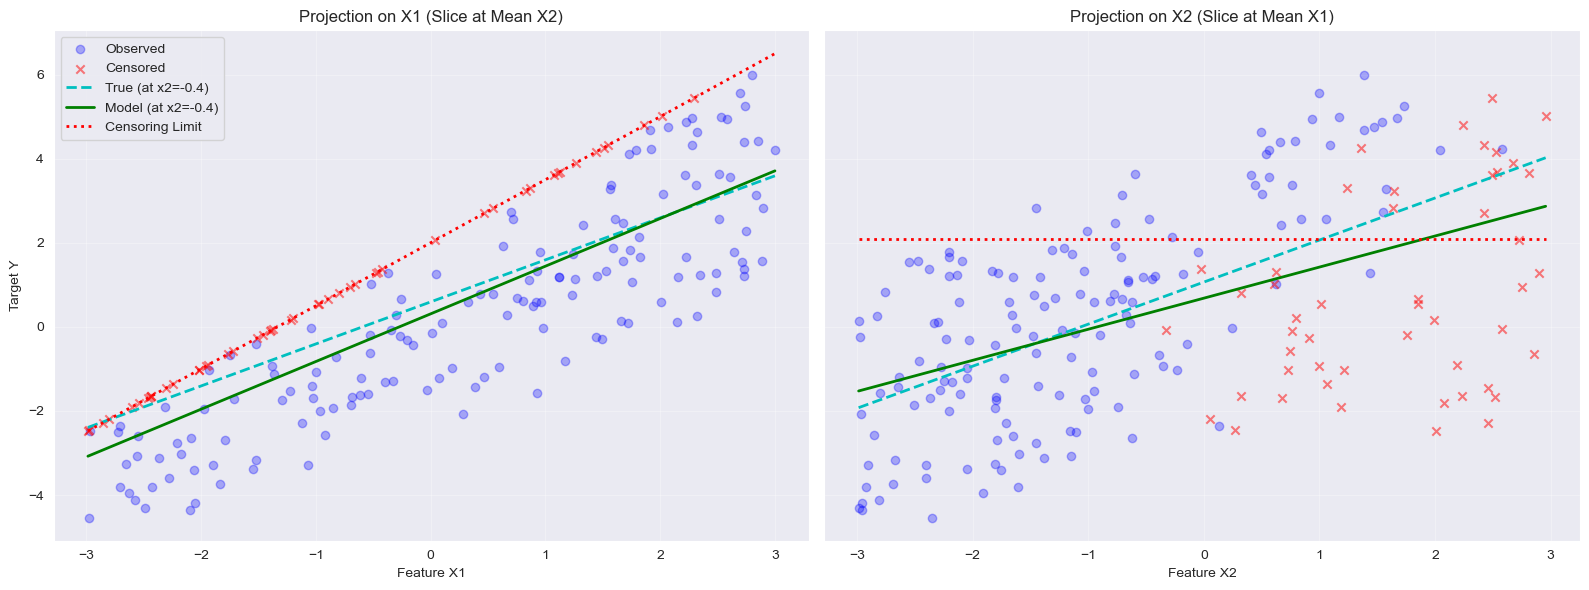

In [8]:
lm_all_data = train_and_predict(x, y, gauss_loss, 1000)
plot_2d_projections(x, y, censoring, 
                            bound_func=diagonal_bounds_2d, 
                            true_fcn=oracle.evaluate_fcn,
                            model=lm_all_data['model'],
                            )

Initializing Model with Input Dimension: 2


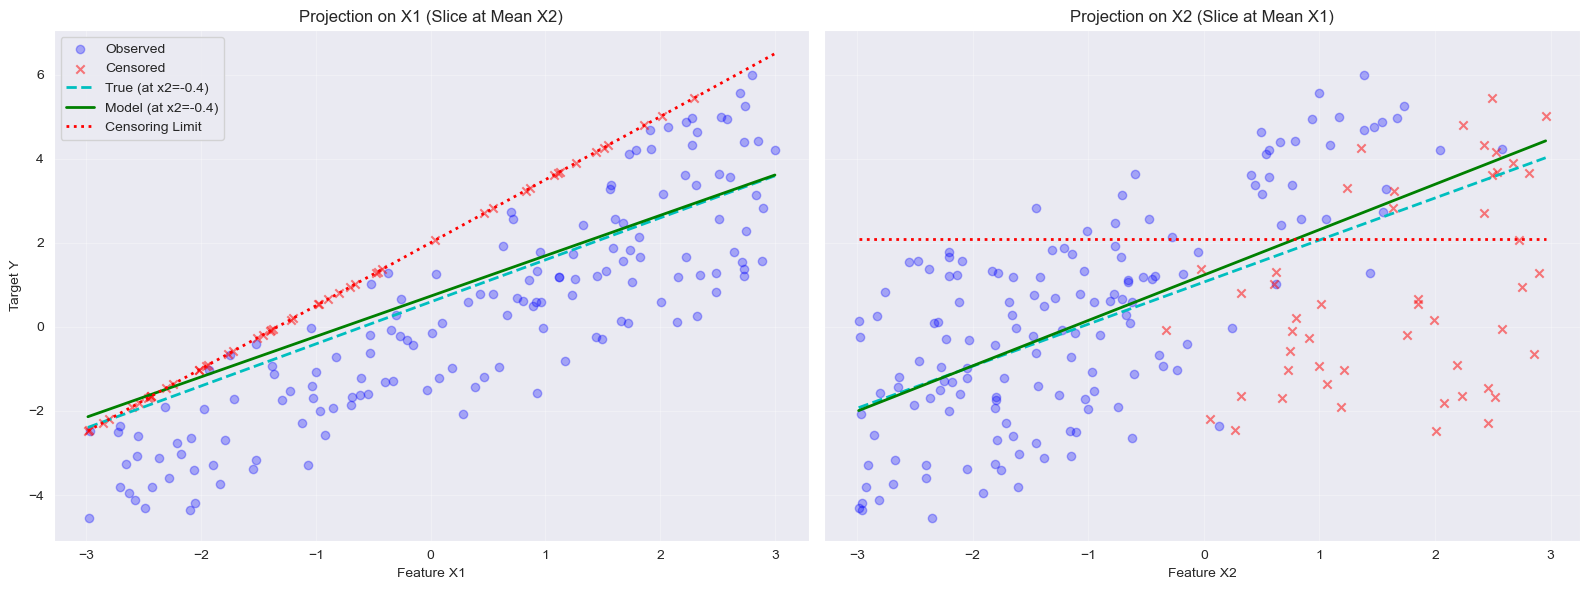

In [9]:
lm_all_data = train_and_predict(x, y, tobit_loss, 1000, censoring)
plot_2d_projections(x, y, censoring, 
                            bound_func=diagonal_bounds_2d, 
                            true_fcn=oracle.evaluate_fcn,
                            model=lm_all_data['model'],
                            )

# 2D Linear model with Variable Bound

In [10]:
def complex_linear_bound(x, y_noisy):
    """
    Implements a specific linear constraint:
    Upper Bound = -0.5 * slope * x1 + 4.0
    """
    # Extract feature 1 (x1)
    x1 = x[:, 0]
    
    # Define a slope parameter (you can tune this)
    bound_slope = 2.0 
    
    # Calculate the upper limit for every point
    # Formula: y < -0.5 * 2.0 * x1 + 4.0  =>  y < -x1 + 4
    upper_bound = -0.5 * bound_slope * x1 + 4.0
    
    # No lower bound
    lower_bound = -bound_slope * x1 + 2.0
    
    return lower_bound, upper_bound

Total Samples: 300
Censored Samples: 100


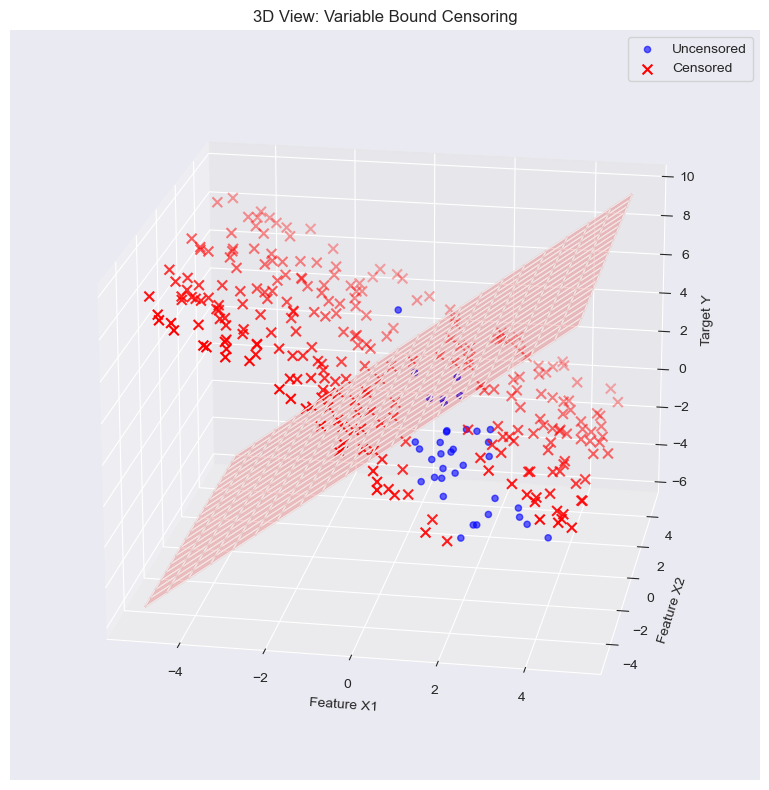

In [11]:
gen2 = VariableBoundGenerator(
    oracle, 
    start=-5.0,        # Expanded range to see the cut clearly
    end=5.0,           
    n_samples=300, 
    noise_scale=1.0,   # Higher noise to make the boundary fuzzy
    bounds_generator=complex_linear_bound, # <--- YOUR NEW FUNCTION
    dim=2              # Essential for 2D
)

x, y, censoring, y_true = gen2.generate()

print(f"Total Samples: {len(y_true)}")
print(f"Censored Samples: {np.sum(censoring == 1)}")

# --- D. Visualize (2D Projections) ---
# We reuse the plotting function from the previous step
plot_3d_censoring(x, y, censoring, bound_func=diagonal_bounds_2d)

Initializing Model with Input Dimension: 2


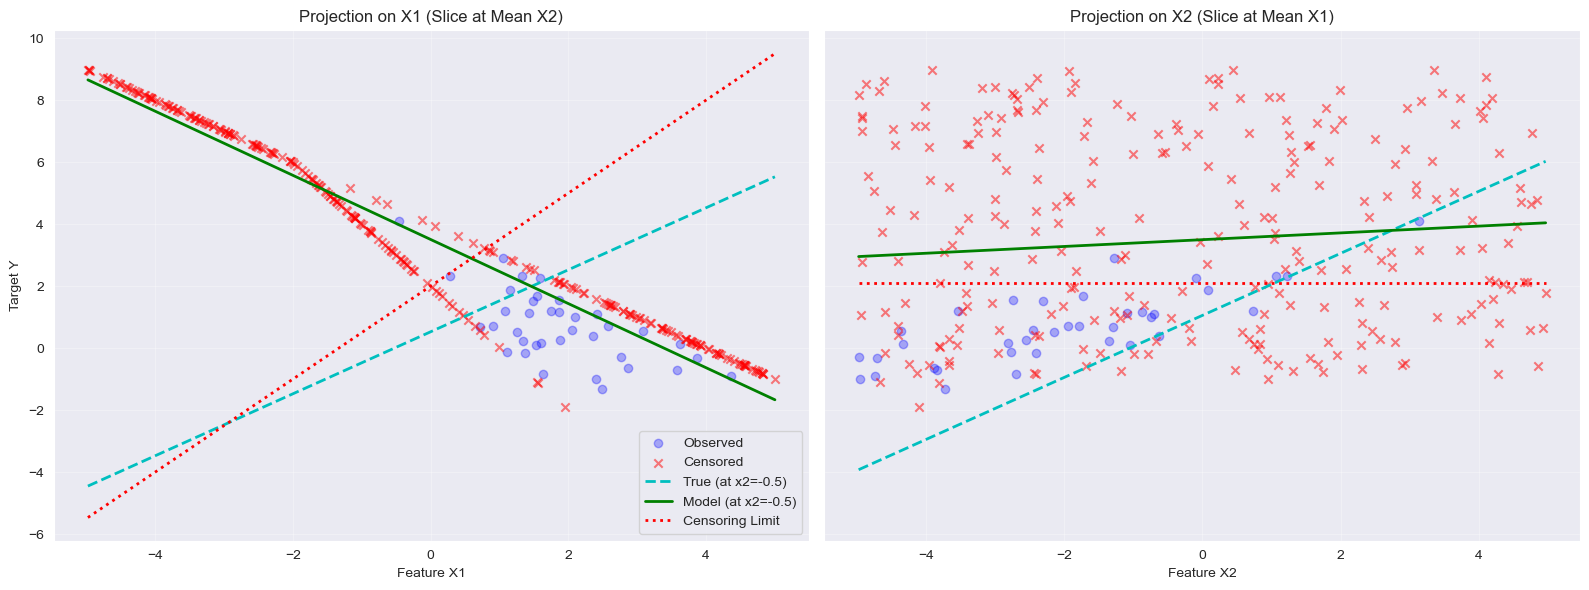

In [12]:
lm_all_data = train_and_predict(x, y, gauss_loss, 1000)
plot_2d_projections(x, y, censoring, 
                            bound_func=diagonal_bounds_2d, 
                            true_fcn=oracle.evaluate_fcn,
                            model=lm_all_data['model'],
                            )

Initializing Model with Input Dimension: 2


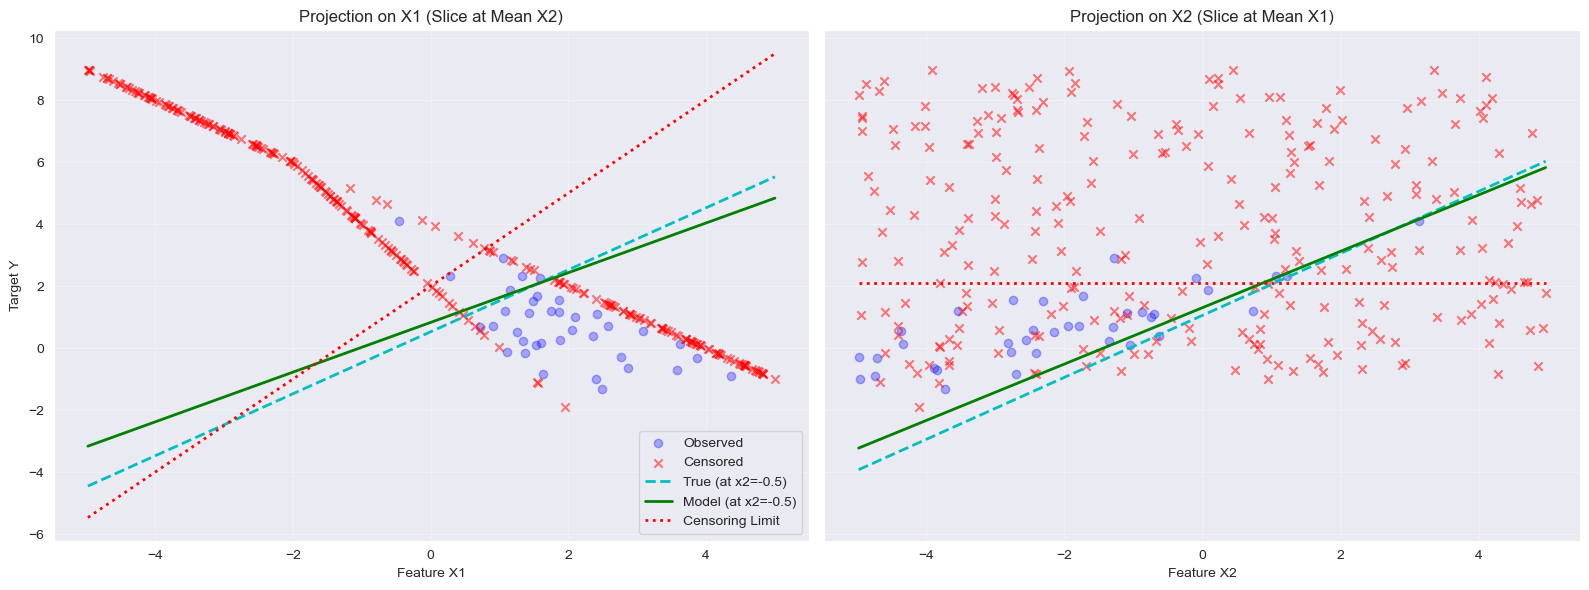

In [13]:
lm_all_data = train_and_predict(x, y, tobit_loss, 1000, censoring)
plot_2d_projections(x, y, censoring, 
                            bound_func=diagonal_bounds_2d, 
                            true_fcn=oracle.evaluate_fcn,
                            model=lm_all_data['model'],
                            )